# Классификация: превышение значением IC50 медианного уровня

В данном ноутбуке решается задача бинарной классификации.

**Цель** - предсказать, превышает ли значение IC50 медианное значение выборки.

Такой подход позволяет перейти от точного предсказания численного значения IC50 к более простой и практичной задаче разделения соединений на две группы.

## 1. Импорт библиотек и загрузка данных

In [ ]:
# Импорт
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import re

# Загрузка данных
df = pd.read_csv('cleaned_data.csv')
print("Размер датасета:", df.shape)

df.head()

Размер датасета: (1001, 78)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,...,fr_para_hydroxylation,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_pyridine,fr_sulfide,fr_sulfone,fr_term_acetylene,fr_thiocyan,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0,...,0,0,0,0,0,0,0,0,0,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0,...,0,0,0,0,0,0,0,0,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0,...,0,0,0,0,0,0,0,0,0,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0,...,0,0,0,0,0,0,0,0,0,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Подготовка данных

Для классификации используется бинарный признак: превышает ли IC50 медианное значение.

In [ ]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
X = df.drop(columns=targets, errors='ignore')
y_raw = df['IC50, mM']

# Создаем бинарный таргет
threshold = y_raw.median()
y_bin = (y_raw > threshold).astype(int)

print(f'Медианное значение IC50 - {threshold}\n')

print('Пропорция распределения:')
y_bin.value_counts(normalize=True)

Медианное значение IC50 - 46.58518345980803

Пропорция распределения:


,proportion
"IC50, mM",
0,0.5005
1,0.4995


Классы получились примерно сбалансированными, так как порог выбран по медиане. Это удобно для обучения моделей и позволяет использовать accuracy наряду с precision, recall и F1

## 3. Разделение на train и test

In [ ]:
# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# Масштабирование
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in df.columns]
    return df

X_train_scaled = clean_column_names(X_train_scaled)
X_test_scaled = clean_column_names(X_test_scaled)

print(f"Размерность X_train: {X_train_scaled.shape}")

Размерность X_train: (800, 75)


## 4. Обучение моделей
Для решения задачи сравним несколько типов моделей:

- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Это позволит понять, какие алгоритмы лучше подходят для разделения соединений по уровню IC50.

In [ ]:
# Базовое сравнение моделей (без настройки)
models = {
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # predict_proba есть не у всех моделей
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc = 0.0

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Модель': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': roc})

res_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print("\nСравнение моделей без настройки:")
display(res_df)



Сравнение моделей без настройки:


,Модель,Accuracy,F1,ROC-AUC
5,GradientBoosting,0.691542,0.720721,0.758267
3,RandomForest,0.686567,0.712329,0.754851
0,KNN,0.701493,0.711538,0.768713
6,LightGBM,0.676617,0.697674,0.741337
2,LogisticRegression,0.666667,0.682464,0.718960
4,ExtraTrees,0.656716,0.672986,0.719802
1,DecisionTree,0.597015,0.604878,0.610792


Наилучший результат по F1 показали `GradientBoostingClassifier` и `RndomForestClassifier`.

Выполним подбор гиперпараметров для наиболее перспективных алгоритмов. В качестве основной метрики используется `F1`, так как она учитывает баланс между `precision` и `recall`.


## 5. Подбор гиперпараметров

### GradientBoosting

In [ ]:
# Настройка GradientBoosting
gbc = GradientBoostingClassifier(random_state=42)

param_grid_gbc = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [1, 2],
}

grid_gbc = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid_gbc,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_gbc.fit(X_train_scaled, y_train)

best_gbc_model = grid_gbc.best_estimator_
print("\nЛучшие параметры GBC:", grid_gbc.best_params_)
print(f"Лучшая F1 на кросс-валидации: {grid_gbc.best_score_:.4f}")

# Оценка на тесте
y_pred_gbc = best_gbc_model.predict(X_test_scaled)
y_prob_gbc = best_gbc_model.predict_proba(X_test_scaled)[:, 1]

acc_gbc = accuracy_score(y_test, y_pred_gbc)
f1_gbc = f1_score(y_test, y_pred_gbc)
roc_gbc = roc_auc_score(y_test, y_prob_gbc)

print(f"\nРезультаты GradientBoosting на тесте:")
print(f"Accuracy: {acc_gbc:.4f}")
print(f"F1-score: {f1_gbc:.4f}")
print(f"ROC-AUC:  {roc_gbc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbc))

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Лучшие параметры GBC: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Лучшая F1 на кросс-валидации: 0.7277

езультаты GradientBoosting на тесте:
Accuracy: 0.6617
F1-score: 0.6852
ROC-AUC:  0.7314

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.58      0.63       101
           1       0.64      0.74      0.69       100

    accuracy                           0.66       201
   macro avg       0.67      0.66      0.66       201
weighted avg       0.67      0.66      0.66       201



- Модель демонстрирует умеренное качество (F1 = 0.68).
- Модель лучше справляется с классом 1 (выше полнота — 0.74).
ROC-AUC выше 0.7, что говорит о наличии ранжирующей способности.
- Низкая полнота (Recall = 0.58) для класса 0  — модель пропускает почти 42% объектов этого класса.
- Общая точность чуть ниже 70%.

### RandomForest

In [ ]:
# Настройка RandomForest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf_model = grid_rf.best_estimator_
print("\nЛучшие параметры RF:", grid_rf.best_params_)
print(f"Лучшая F1 на кросс-валидации: {grid_rf.best_score_:.4f}")

# Оценка на тесте
y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\nРезультаты RandomForest на тесте:")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC-AUC:  {roc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Лучшие параметры RF: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая F1 на кросс-валидации: 0.7260

Результаты RandomForest на тесте:
Accuracy: 0.7114
F1-score: 0.7339
ROC-AUC:  0.7743

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68       101
           1       0.68      0.80      0.73       100

    accuracy                           0.71       201
   macro avg       0.72      0.71      0.71       201
weighted avg       0.72      0.71      0.71       201



- Модель демонстрирует хорошее качество (F1 = 0.73), что лучше, чем у GradientBoosting.
- Высокий ROC-AUC (0.7743) — модель хорошо ранжирует объекты.
- Хорошая полнота (Recall) для класса 1 (0.80) — модель редко пропускает объекты с высоким IC50.
- Низкая полнота (Recall) для класса 0 (0.62) — модель пропускает почти 38% объектов этого класса.

## Выбираем лучшую модель

In [ ]:
# Выбираем лучшую модель
if f1_rf >= f1_gbc:
    best_final_model = best_rf_model
    best_final_name = "RandomForest"
    y_pred_final = y_pred_rf
else:
    best_final_model = best_gbc_model
    best_final_name = "GradientBoosting"
    y_pred_final = y_pred_gbc

print(f'Лучшая модель - {best_final_name}')

Лучшая модель - RandomForest


- После подбора гиперпараметров лучшей моделью стала RandomForestClassifier.
- По сравнению с первичным сравнением моделей качество улучшилось: значение F1 увеличилось (0.726 против 0.712), ROC-AUC стал выше (0.774 против 0.755)
- Таким образом, `RandomForestClassifier` был выбран в качестве финальной модели для задачи классификации IC50 относительно медианы.

## Матрица ошибок (Confusion Matrix) и ROC-кривая

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно

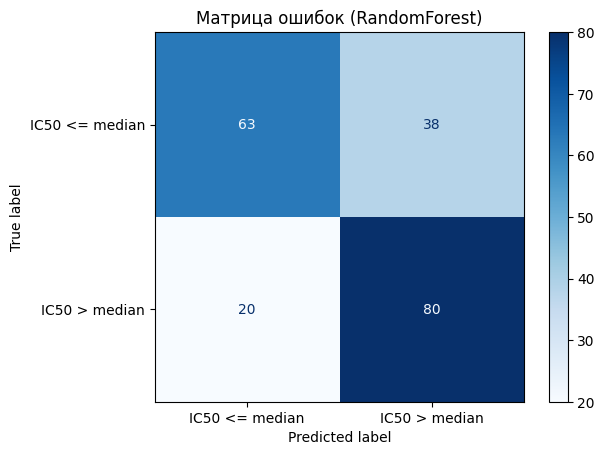

<Figure size 800x600 with 0 Axes>

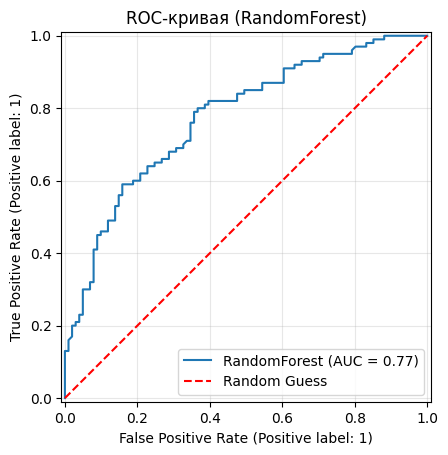

In [ ]:
# Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["IC50 <= median", "IC50 > median"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Матрица ошибок ({best_final_name})")
plt.grid(False)
plt.show()

# ROC-кривая
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    best_final_model,
    X_test_scaled,
    y_test,
    name=best_final_name
)
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random Guess")
plt.title(f"ROC-кривая ({best_final_name})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Матрица ошибок показывает, что модель достаточно хорошо разделяет соединения по значению IC50 относительно медианы. Модель правильно классифицировала 63 объекта класса `IC50 <= median` и 80 объектов класса `IC50 > median`.

- Модель допустила 38 ложноположительных ошибок и 20 ложноотрицательных ошибок.

- ROC-кривая показывает, что модель хорошо отделяет соединения с IC50 выше медианы от остальных. Значение AUC составляет около 0.77, что заметно выше случайного угадывания 0.5.

## Выводы

- В рамках задачи построена модель бинарной классификации для определения, превышает ли IC50 медианное значение.
- Целевую переменную сформировали через медиану — это обеспечило сбалансированность классов и позволило корректно использовать метрики accuracy, F1 и ROC‑AUC.
- На этапе сравнения лучших результатов достигли ансамблевые методы; после подбора гиперпараметров лидером стал RandomForestClassifier. Его показатели на тестовой выборке: accuracy = 0.71, F1 = 0.73, ROC‑AUC = 0.77.
- Матрица ошибок и ROC‑кривая подтверждают, что модель устойчиво разделяет классы: верно классифицировано 63 объекта в классе «IC50 <= median» и 80 — в классе «IC50 > median».
- **Результат существенно лучше случайного угадывания.**